1. Импортируем необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Настройка отображения графиков
%matplotlib inline
sns.set_style("whitegrid")

2. Загрузка данных

In [ ]:
df = pd.read_csv('school.csv')
print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика:")
print(df.describe())

Размер данных: (25, 5)

Первые 5 строк:
    School   4R   4A   6R   6A
0  Baldwin  2.7  3.2  4.5  4.8
1  Barnard  3.9  3.8  5.9  6.2
2  Beecher  4.8  4.1  6.8  5.5
3  Brennan  3.1  3.5  4.3  4.6
4  Clinton  3.4  3.7  5.1  5.6

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   School  25 non-null     str    
 1   4R      25 non-null     float64
 2   4A      25 non-null     float64
 3   6R      25 non-null     float64
 4   6A      25 non-null     float64
dtypes: float64(4), str(1)
memory usage: 1.1 KB
None

Статистика:
              4R         4A         6R         6A
count  25.000000  25.000000  25.000000  25.000000
mean    3.656000   3.708000   5.276000   5.400000
std     0.767615   0.540771   1.097072   0.627163
min     2.700000   3.000000   4.000000   4.600000
25%     3.100000   3.300000   4.500000   5.000000
50%     3.400000   3.600000   5.1000

3. Разведочный анализ данных (EDA)

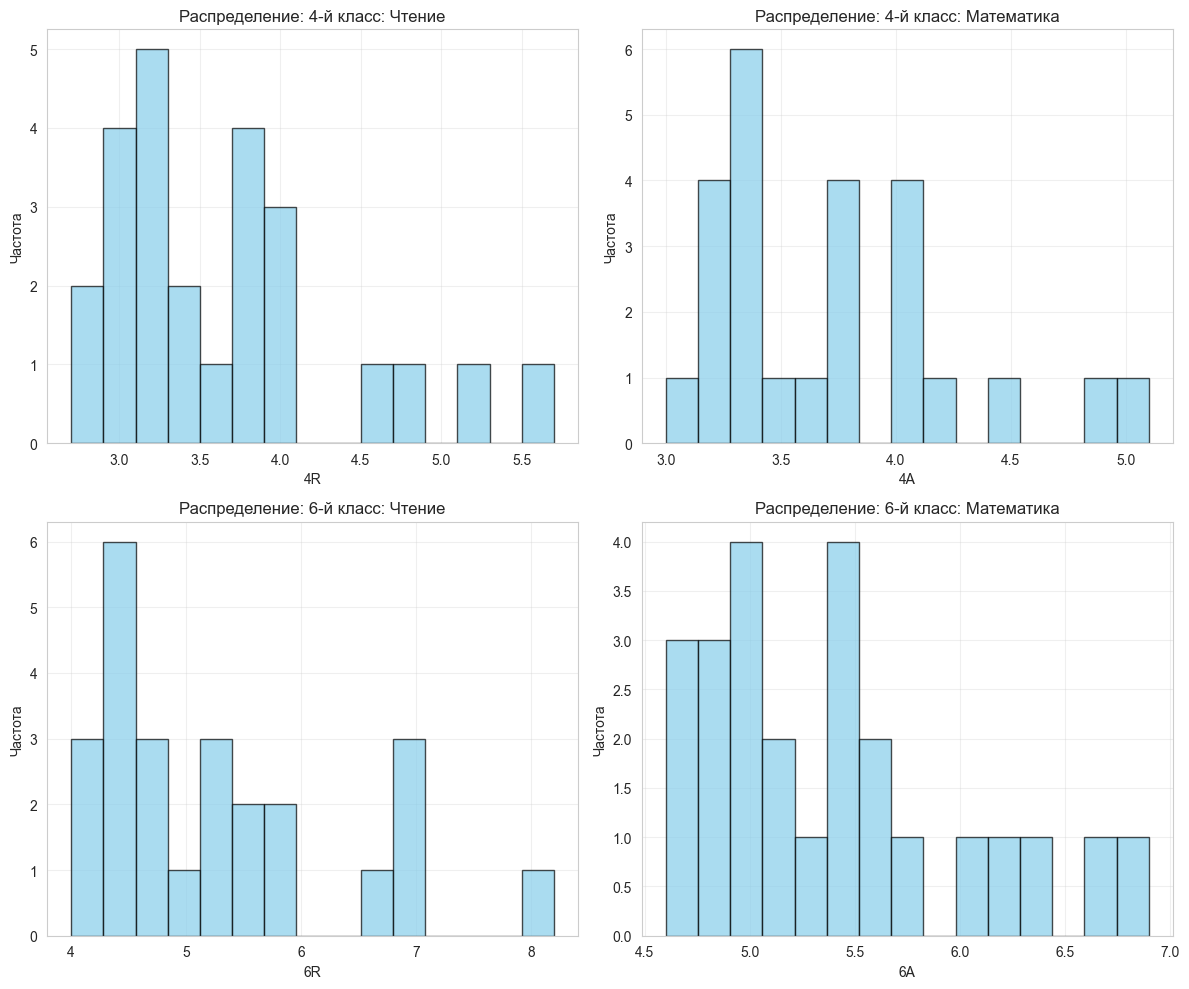

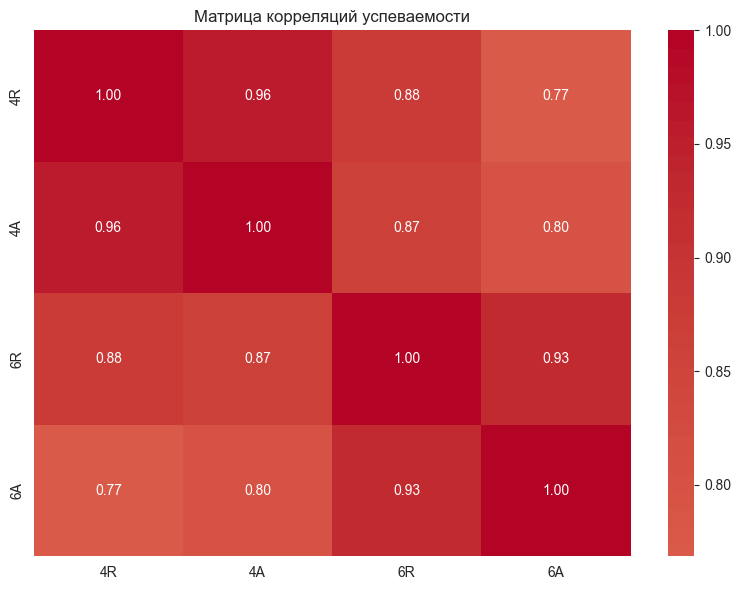

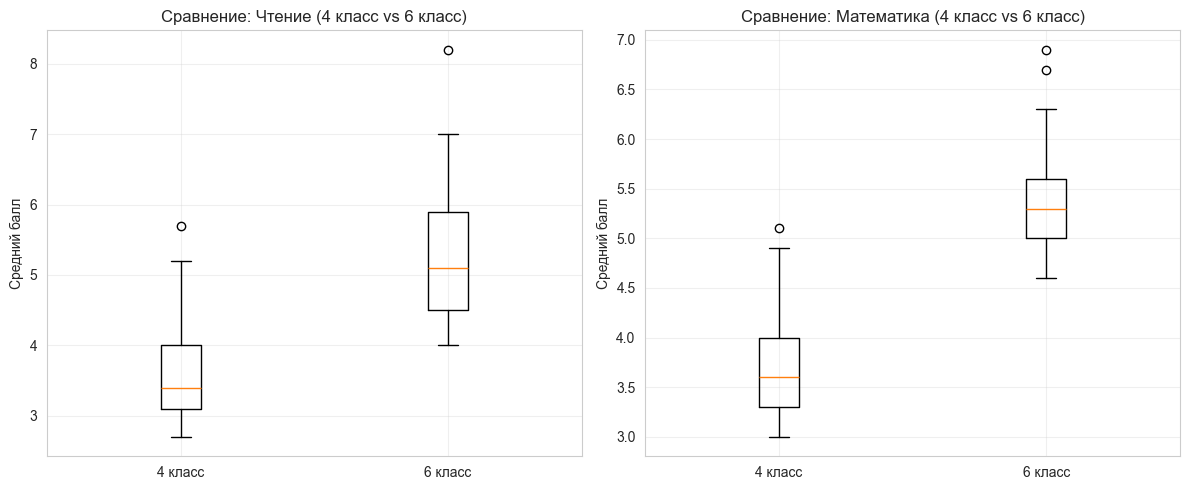

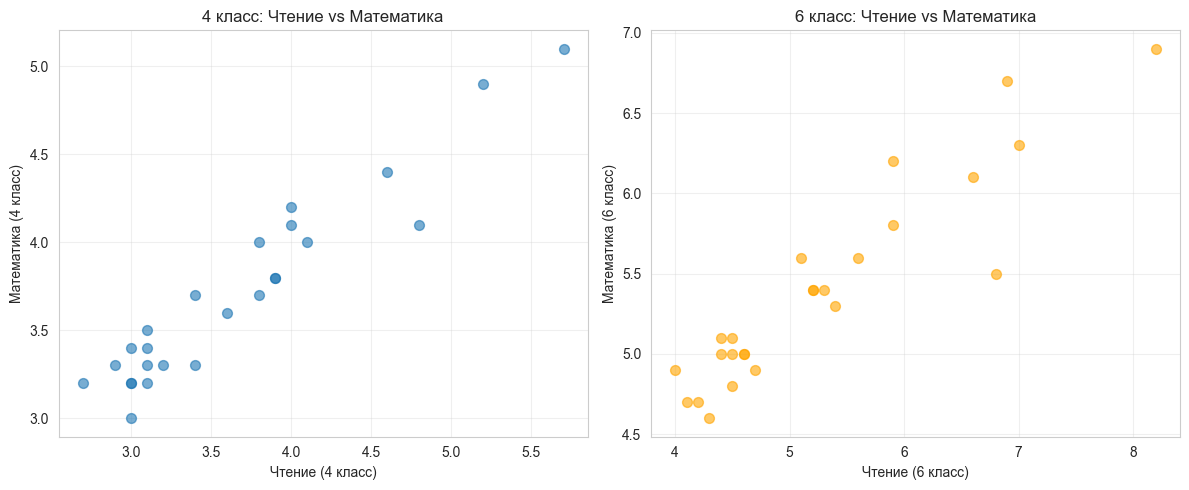

In [7]:
# Гистограммы распределений
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

features = ['4R', '4A', '6R', '6A']
titles = ['4-й класс: Чтение', '4-й класс: Математика', '6-й класс: Чтение', '6-й класс: Математика']

for i, (feature, title) in enumerate(zip(features, titles)):
    axes[i].hist(df[feature], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')
    axes[i].set_title(f'Распределение: {title}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(8, 6))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций успеваемости')
plt.tight_layout()
plt.show()

# Boxplot'ы для каждого предмета
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение 4-го и 6-го класса по чтению
data_to_plot = [df['4R'], df['6R']]
axes[0].boxplot(data_to_plot, tick_labels=['4 класс', '6 класс'])
axes[0].set_title('Сравнение: Чтение (4 класс vs 6 класс)')
axes[0].set_ylabel('Средний балл')
axes[0].grid(True, alpha=0.3)

# Сравнение 4-го и 6-го класса по математике
data_to_plot = [df['4A'], df['6A']]
axes[1].boxplot(data_to_plot, tick_labels=['4 класс', '6 класс'])
axes[1].set_title('Сравнение: Математика (4 класс vs 6 класс)')
axes[1].set_ylabel('Средний балл')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Диаграммы рассеяния
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 4 класс: Чтение vs Математика
axes[0].scatter(df['4R'], df['4A'], alpha=0.6, s=50)
axes[0].set_xlabel('Чтение (4 класс)')
axes[0].set_ylabel('Математика (4 класс)')
axes[0].set_title('4 класс: Чтение vs Математика')
axes[0].grid(True, alpha=0.3)

# 6 класс: Чтение vs Математика
axes[1].scatter(df['6R'], df['6A'], alpha=0.6, s=50, color='orange')
axes[1].set_xlabel('Чтение (6 класс)')
axes[1].set_ylabel('Математика (6 класс)')
axes[1].set_title('6 класс: Чтение vs Математика')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4. Предобработка данных

In [11]:
# Копируем исходный датафрейм для обработки
df_processed = df.copy()

# Удаление нечислового столбца School (если он есть)
if 'School' in df_processed.columns:
    df_processed = df_processed.drop(columns=['School'])
    print("Удален столбец 'School' (идентификатор)")

# Нормализация данных
scaler = StandardScaler()
features_to_scale = df_processed.columns.tolist()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_processed),
    columns=features_to_scale
)

print(f"Размер после предобработки: {df_scaled.shape}")
print("Первые 5 строк после нормализации:")
print(df_scaled.head())

Удален столбец 'School' (идентификатор)
Размер после предобработки: (25, 4)
Первые 5 строк после нормализации:
         4R        4A        6R        6A
0 -1.271097 -0.958770 -0.721923 -0.976417
1  0.324422  0.173636  0.580516  1.301889
2  1.521061  0.739839  1.417798  0.162736
3 -0.739257 -0.392567 -0.907986 -1.301889
4 -0.340377 -0.015099 -0.163735  0.325472


5. Обучение модели k-средних

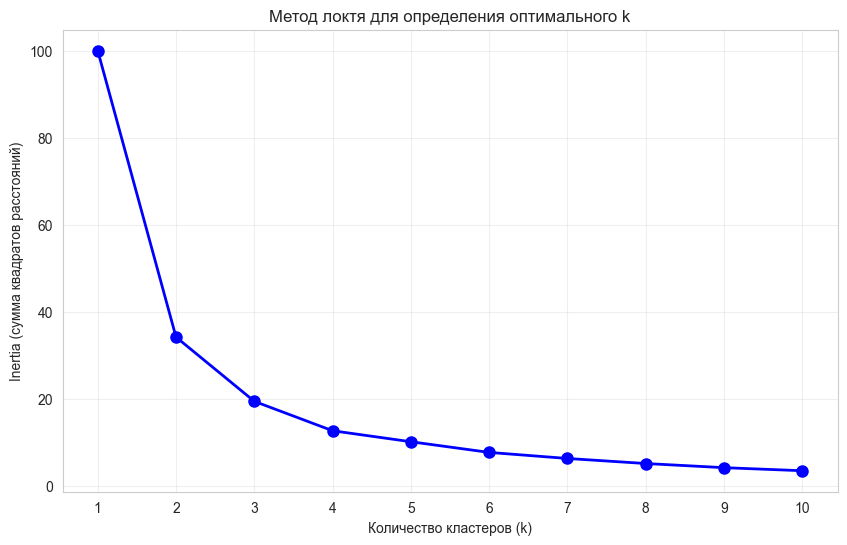

Оптимальное количество кластеров: 3
Распределение по кластерам:
Cluster
0    13
1     2
2    10
Name: count, dtype: int64


In [12]:
# Определение оптимального числа кластеров (метод локтя)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia (сумма квадратов расстояний)')
plt.title('Метод локтя для определения оптимального k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

# Выбор оптимального k (по графику "локтя")
optimal_k = 3  # На графике виден "локоть" на k=3
print(f"Оптимальное количество кластеров: {optimal_k}")

# Обучение модели с оптимальным k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Добавление меток кластеров в исходный датафрейм
df['Cluster'] = clusters
df_scaled['Cluster'] = clusters

print(f"Распределение по кластерам:\n{df['Cluster'].value_counts().sort_index()}")

6. Снижение размерности с помощью PCA

Доля объясненной дисперсии PC1: 0.900
Доля объясненной дисперсии PC2: 0.076
Суммарная доля: 0.976


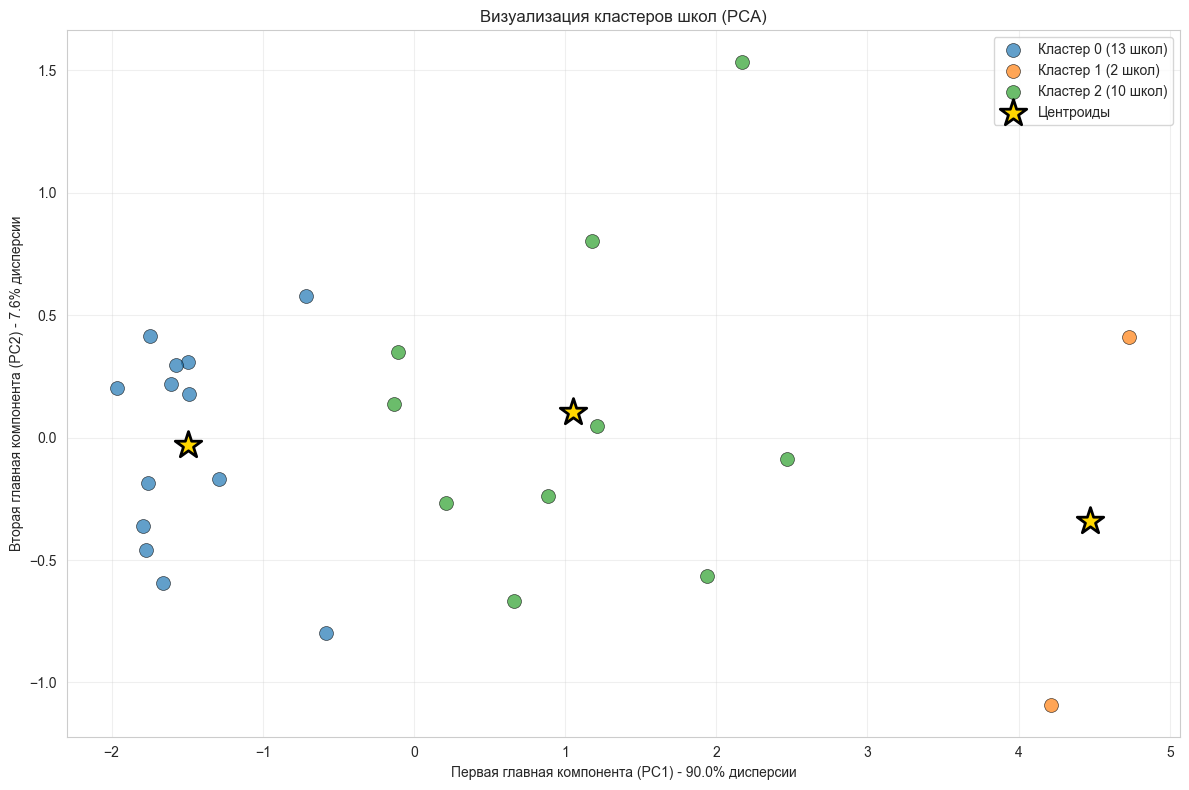

In [14]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop(columns=['Cluster']))
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

print(f"Доля объясненной дисперсии PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Доля объясненной дисперсии PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарная доля: {sum(pca.explained_variance_ratio_):.3f}")

# Визуализация кластеров в 2D (PCA)
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.arange(10) / 10)

for i in range(optimal_k):
    cluster_mask = clusters == i
    plt.scatter(pca_result[cluster_mask, 0], pca_result[cluster_mask, 1],
                s=100, alpha=0.7, color=colors[i],
                label=f'Кластер {i} ({np.sum(cluster_mask)} школ)',
                edgecolors='black', linewidth=0.5)

# Центроиды в пространстве PCA
centroids_scaled = kmeans.cluster_centers_
centroids_df = pd.DataFrame(centroids_scaled, columns=df_scaled.drop(columns=['Cluster']).columns)
centroids_pca = pca.transform(centroids_df)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=400, color='gold', marker='*',
            edgecolor='black', linewidth=2,
            label='Центроиды', zorder=5)

plt.xlabel(f'Первая главная компонента (PC1) - {pca.explained_variance_ratio_[0]:.1%} дисперсии')
plt.ylabel(f'Вторая главная компонента (PC2) - {pca.explained_variance_ratio_[1]:.1%} дисперсии')
plt.title('Визуализация кластеров школ (PCA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

7. Разведочный анализ по кластерам

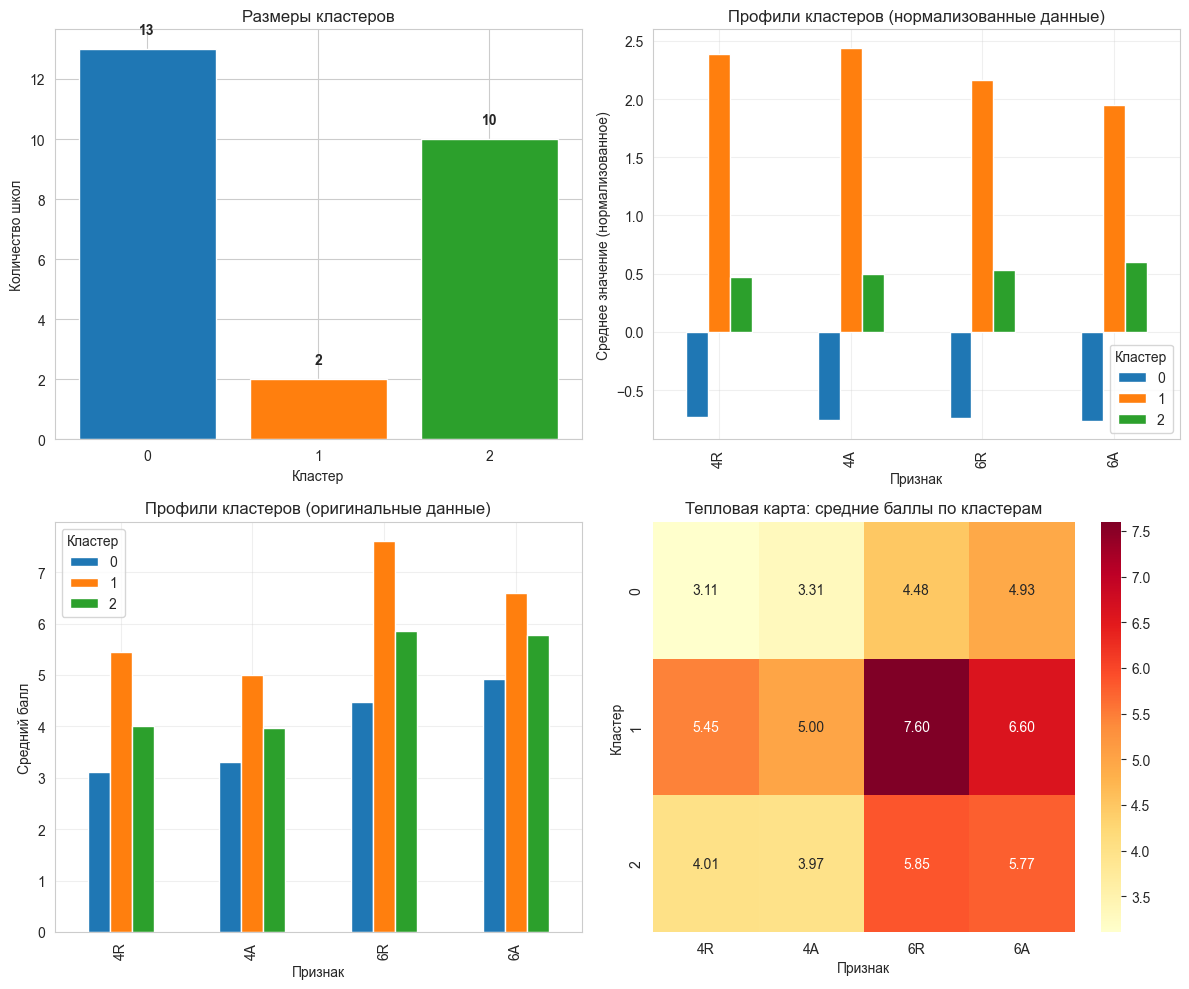


=== ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===

1. Silhouette Score: 0.5125
   Интерпретация:
   ✓ Хорошая кластеризация

2. Calinski-Harabasz Index: 45.35
   (Отношение дисперсии между кластерами к дисперсии внутри кластеров)
   Чем выше значение, тем лучше разделение кластеров

3. Davies-Bouldin Index: 0.6022
   (Среднее сходство каждого кластера с наиболее похожим кластером)
   0 - лучший результат, чем меньше значение, тем лучше

4. Inertia (WCSS): 19.52
   (Сумма квадратов расстояний точек до центроидов их кластеров)
   Чем меньше значение, тем более компактны кластеры

=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===

Кластер 0:
  - Количество школ: 13
  - Средний балл (4R): 3.11
  - Средний балл (4A): 3.31
  - Средний балл (6R): 4.48
  - Средний балл (6A): 4.93
  → Характеристика: Школы с низкими показателями

Кластер 1:
  - Количество школ: 2
  - Средний балл (4R): 5.45
  - Средний балл (4A): 5.00
  - Средний балл (6R): 7.60
  - Средний балл (6A): 6.60
  → Характеристика: Школы с высокими показателями


In [15]:
# Визуализация характеристик кластеров
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Размеры кластеров
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color=colors[:optimal_k])
axes[0, 0].set_xlabel('Кластер')
axes[0, 0].set_ylabel('Количество школ')
axes[0, 0].set_title('Размеры кластеров')
axes[0, 0].set_xticks(range(optimal_k))
for i, v in enumerate(cluster_counts.values):
    axes[0, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Средние значения по кластерам (нормализованные)
cluster_means_scaled = df_scaled.groupby('Cluster').mean()
cluster_means_scaled.T.plot(kind='bar', ax=axes[0, 1], color=colors[:optimal_k])
axes[0, 1].set_xlabel('Признак')
axes[0, 1].set_ylabel('Среднее значение (нормализованное)')
axes[0, 1].set_title('Профили кластеров (нормализованные данные)')
axes[0, 1].legend(title='Кластер')
axes[0, 1].grid(True, alpha=0.3)

# Средние значения по кластерам (оригинальные)
cluster_means_orig = df.groupby('Cluster')[features].mean()
cluster_means_orig.T.plot(kind='bar', ax=axes[1, 0], color=colors[:optimal_k])
axes[1, 0].set_xlabel('Признак')
axes[1, 0].set_ylabel('Средний балл')
axes[1, 0].set_title('Профили кластеров (оригинальные данные)')
axes[1, 0].legend(title='Кластер')
axes[1, 0].grid(True, alpha=0.3)

# Тепловая карта средних значений
sns.heatmap(cluster_means_orig, annot=True, cmap='YlOrRd', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Тепловая карта: средние баллы по кластерам')
axes[1, 1].set_xlabel('Признак')
axes[1, 1].set_ylabel('Кластер')

plt.tight_layout()
plt.show()

# Метрики качества кластеризации
print("\n=== ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ===")

silhouette_avg = silhouette_score(df_scaled.drop(columns=['Cluster']), clusters)
print(f"\n1. Silhouette Score: {silhouette_avg:.4f}")
print("   Интерпретация:")
if silhouette_avg > 0.7:
    print("    Отличная кластеризация")
elif silhouette_avg > 0.5:
    print("   ✓ Хорошая кластеризация")
elif silhouette_avg > 0.25:
    print("   ○ Умеренная кластеризация")
else:
    print("   ✗ Низкое качество")

ch_score = calinski_harabasz_score(df_scaled.drop(columns=['Cluster']), clusters)
print(f"\n2. Calinski-Harabasz Index: {ch_score:.2f}")
print("   (Отношение дисперсии между кластерами к дисперсии внутри кластеров)")
print("   Чем выше значение, тем лучше разделение кластеров")

db_score = davies_bouldin_score(df_scaled.drop(columns=['Cluster']), clusters)
print(f"\n3. Davies-Bouldin Index: {db_score:.4f}")
print("   (Среднее сходство каждого кластера с наиболее похожим кластером)")
print("   0 - лучший результат, чем меньше значение, тем лучше")

inertia_val = kmeans.inertia_
print(f"\n4. Inertia (WCSS): {inertia_val:.2f}")
print("   (Сумма квадратов расстояний точек до центроидов их кластеров)")
print("   Чем меньше значение, тем более компактны кластеры")

# Интерпретация кластеров
print("\n=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===")
for i in range(optimal_k):
    print(f"\nКластер {i}:")
    cluster_data = df[df['Cluster'] == i]
    print(f"  - Количество школ: {len(cluster_data)}")
    print(f"  - Средний балл (4R): {cluster_data['4R'].mean():.2f}")
    print(f"  - Средний балл (4A): {cluster_data['4A'].mean():.2f}")
    print(f"  - Средний балл (6R): {cluster_data['6R'].mean():.2f}")
    print(f"  - Средний балл (6A): {cluster_data['6A'].mean():.2f}")
    
    # Характеристика кластера
    if cluster_data['4R'].mean() > 4.5 and cluster_data['6R'].mean() > 6:
        print("  → Характеристика: Школы с высокими показателями")
    elif cluster_data['4R'].mean() < 3.5 and cluster_data['6R'].mean() < 5:
        print("  → Характеристика: Школы с низкими показателями")
    else:
        print("  → Характеристика: Школы со средними показателями")